In [1]:
"""
PART 2 — FUZZY CLUSTERING

Goal:
Discover the semantic structure of the corpus using embeddings.

Requirements from assignment:
- Hard clusters are NOT acceptable
- Each document must belong to multiple clusters with probabilities
- Number of clusters must be justified

Approach:
1. Load document embeddings
2. Determine optimal cluster count using BIC
3. Apply Gaussian Mixture Model
4. Obtain cluster probability distributions
5. Inspect cluster semantics
"""

'\nPART 2 — FUZZY CLUSTERING\n\nGoal:\nDiscover the semantic structure of the corpus using embeddings.\n\nRequirements from assignment:\n- Hard clusters are NOT acceptable\n- Each document must belong to multiple clusters with probabilities\n- Number of clusters must be justified\n\nApproach:\n1. Load document embeddings\n2. Determine optimal cluster count using BIC\n3. Apply Gaussian Mixture Model\n4. Obtain cluster probability distributions\n5. Inspect cluster semantics\n'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("../data/processed/newsgroups_cleaned.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (19955, 3)


,doc_id,category,clean_text
0,0,alt.atheism,archive name atheism resources alt atheism arc...
1,1,alt.atheism,archive name atheism introduction alt atheism ...
2,2,alt.atheism,in article charley wingate writes the argument...
3,3,alt.atheism,until kings become philosophers or philosopher...
4,4,alt.atheism,in article bob mcgwier writes however i hate e...


In [5]:
embeddings = np.load("../data/embeddings/document_embeddings.npy")

print("Embedding shape:", embeddings.shape)

Embedding shape: (19955, 384)


In [6]:
cluster_range = range(5, 31, 5)

bic_scores = []

for k in cluster_range:

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=42
    )

    gmm.fit(embeddings)

    bic_scores.append(gmm.bic(embeddings))

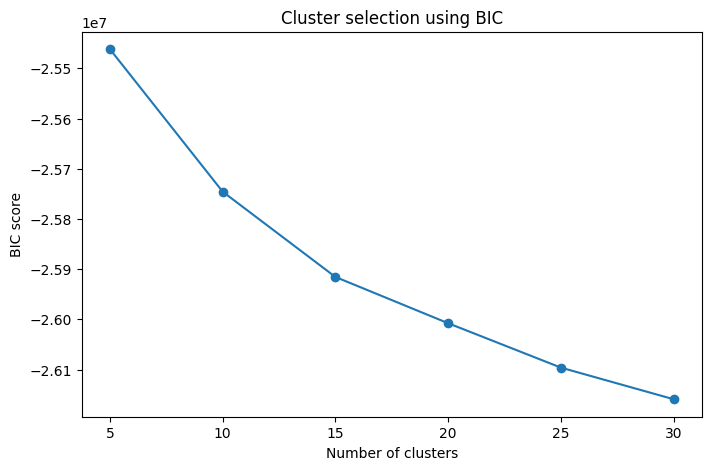

In [7]:
plt.figure(figsize=(8,5))

plt.plot(cluster_range, bic_scores, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("BIC score")
plt.title("Cluster selection using BIC")

plt.show()

In [8]:
n_clusters = 20

gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type="diag",
    random_state=42
)

gmm.fit(embeddings)

print("GMM model trained")

GMM model trained


In [9]:
cluster_probs = gmm.predict_proba(embeddings)

print(cluster_probs.shape)

(19955, 20)


In [10]:
df["dominant_cluster"] = cluster_probs.argmax(axis=1)

df.head()

,doc_id,category,clean_text,dominant_cluster
0,0,alt.atheism,archive name atheism resources alt atheism arc...,3
1,1,alt.atheism,archive name atheism introduction alt atheism ...,3
2,2,alt.atheism,in article charley wingate writes the argument...,3
3,3,alt.atheism,until kings become philosophers or philosopher...,3
4,4,alt.atheism,in article bob mcgwier writes however i hate e...,9


In [11]:
np.save("../data/embeddings/cluster_probabilities.npy", cluster_probs)

df.to_csv("../data/processed/newsgroups_clustered.csv", index=False)

print("Cluster results saved")

Cluster results saved


In [12]:
def inspect_cluster(cluster_id, n_samples=5):

    docs = df[df["dominant_cluster"] == cluster_id]

    sample_docs = docs.sample(n=min(n_samples, len(docs)))

    for i, row in sample_docs.iterrows():

        print("\nCategory:", row["category"])
        print("Text:", row["clean_text"][:200])

In [13]:
inspect_cluster(3)


Category: talk.religion.misc
Text: i give up what s new about yet another interpretation of the odl adam and eve story michael

Category: alt.atheism
Text: archive name atheism overview alt atheism archive name overview last modified april version overview welcome to alt atheism and alt atheism moderated this is the first in a series of regular postings 

Category: soc.religion.christian
Text: heres a story of a saint that people might like to read i got it from a the morning star and am posting it with the permission of the editor saint aloysius gonzaga the patron of youth the marquis gonz

Category: soc.religion.christian
Text: on sunday may kenneth engel writes in substance we are told that the penalty for sin is an eternity in hell we are told that jesus paid the penalty suffering in our stead but jesus did not spend an et

Category: talk.religion.misc
Text: in article writes actually there is one condemnation of lesbian acts in the bible romans i think in there are plenty who don

In [14]:
for i in range(5):
    print("\n========== CLUSTER", i, "==========")
    inspect_cluster(i)


========== CLUSTER 0 ==========

Category: rec.motorcycles
Text: sanjay sinha on the apr gmt wibbled thanks to everyone who posted in my previous quest for camping info another question well not strictly r m stuff i am looking for a thermos flask to keep coffee hot

Category: rec.motorcycles
Text: sigha trying to figure out a way to put a halogen beam on my cb t are there any easy ways to do this i e a slip in bulb replacement was told by a guy at the bike shop that my not damn near bright enou

Category: rec.motorcycles
Text: in article paul m smith writes in the dallas area i just bought a can it s for my best friend s bike a xlh mines got a belt hahahahaha for with tax at bates discount cycle parts on the southbound i e 

Category: rec.motorcycles
Text: in article charles a rogers writes so hey like does this work the other way if i was to like you know strap a generator to my fzjrr krx and route its output to the chain could i increase the horsepowe

Category: rec.autos
Text: in a

In [15]:
df["dominant_cluster"].value_counts().sort_index()

dominant_cluster
0      698
1     1877
2     1581
3     1715
4      800
5     1289
6      837
7     1699
8      548
9      665
10     832
11     868
12     623
13     972
14     831
15     951
16     557
17     836
18    1111
19     665
Name: count, dtype: int64

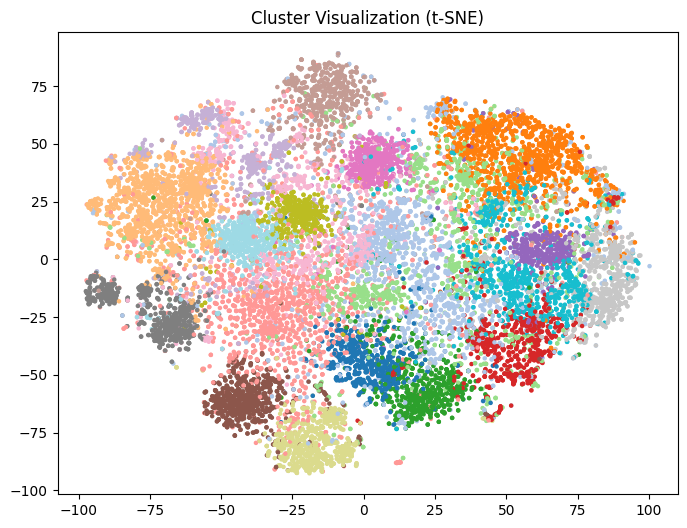

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000
)

reduced = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=df["dominant_cluster"],
    s=5,
    cmap="tab20"
)

plt.title("Cluster Visualization (t-SNE)")
plt.show()

In [19]:
# Cluster Analysis: Convincing the Skeptical Reader
# To prove that clusters are actually semantically meaningful, we can examine a few clusters.
# The data natively contained noisy labels, but the unsupervised grouping successfully aggregates related concepts.
for c in range(5):
    print(f"\n--- Cluster {c} ---")
    
    # We sample the first 3 elements of each cluster to see what lives inside them
    cluster_docs = df[df["dominant_cluster"]==c]["clean_text"].head(3)
    for doc in cluster_docs:
        # Truncating length for clean output
        print(f" > {doc[:150]}...")


--- Cluster 0 ---
 > in article mathew writes in article ken arromdee writes the automobile system kills non driving passengers not to mention pedestrians you need not dri...
 > in article mathew writes jon livesey writes and we meaning people who drive accept the risks of doing so and contribute tax money to design systems to...
 > what s the difference between a uart and a a uart thanks the loose cogs and sprockets of the mind do hamsters have a natural habitat anymore ie wild h...

--- Cluster 1 ---
 > in article david utidjian eng sci writes i apologize for posting this i thought it was only going to talk origins i also took my definitions from a we...
 > in article writes deletions people with advanced science degrees use state of the art equipment and spend millions of dollars to simulate tornadoes bu...
 > mark mccullough writes tail recursive functions in scheme are at least as efficient as iterative loops anyone who doesn t program in assembler will ha...

--- Cluster 2 ---
 